In [1]:
from src.helpers.gromacs import *

Helper functions loaded.



Psychrophilic - Predicted
Final RMSD:         0.970 nm (9.7 Å)
Mean RMSD:          0.872 nm (8.7 Å)
Mean (last 25%):    1.016 nm (10.2 Å)

Psychrophilic - Crystal
Final RMSD:         0.255 nm (2.6 Å)
Mean RMSD:          0.236 nm (2.4 Å)
Mean (last 25%):    0.246 nm (2.5 Å)

Mesophilic - Predicted
Final RMSD:         1.215 nm (12.2 Å)
Mean RMSD:          0.962 nm (9.6 Å)
Mean (last 25%):    1.223 nm (12.2 Å)

Mesophilic - Crystal
Final RMSD:         0.264 nm (2.6 Å)
Mean RMSD:          0.246 nm (2.5 Å)
Mean (last 25%):    0.263 nm (2.6 Å)

Thermophilic - Predicted
Final RMSD:         1.267 nm (12.7 Å)
Mean RMSD:          1.147 nm (11.5 Å)
Mean (last 25%):    1.210 nm (12.1 Å)

Thermophilic - Crystal
Final RMSD:         0.270 nm (2.7 Å)
Mean RMSD:          0.257 nm (2.6 Å)
Mean (last 25%):    0.274 nm (2.7 Å)


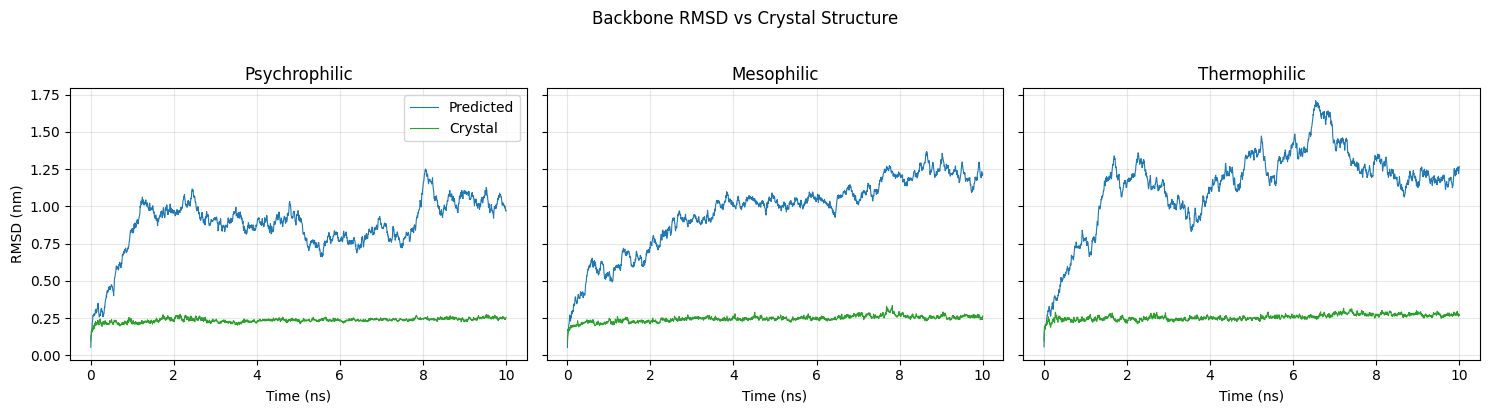

In [16]:
import matplotlib.pyplot as plt
import numpy as np

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/uvsx/psychrophilic/results/rmsd.xvg',
    'Mesophilic': 'predicted/alphafold/uvsx/mesophilic/results/rmsd.xvg',
    'Thermophilic': 'predicted/alphafold/uvsx/thermophilic/results/rmsd.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/3IO5/psychrophilic/results/rmsd.xvg',
    'Mesophilic': 'crystal/3IO5/mesophilic/results/rmsd.xvg',
    'Thermophilic': 'crystal/3IO5/thermophilic/results/rmsd.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rmsd = d["columns"][:, 0]

        ax.plot(x, rmsd, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Final RMSD:         {rmsd[-1]:.3f} nm ({rmsd[-1]*10:.1f} Å)")
        print(f"Mean RMSD:          {np.mean(rmsd):.3f} nm ({np.mean(rmsd)*10:.1f} Å)")
        print(f"Mean (last 25%):    {np.mean(rmsd[len(rmsd)*3//4:]):.3f} nm "
              f"({np.mean(rmsd[len(rmsd)*3//4:])*10:.1f} Å)")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("RMSD (nm)")
axes[0].legend()

fig.suptitle("Backbone RMSD vs Crystal Structure", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/UvsX_vs_3IO5_RMSD.png', dpi=300, bbox_inches='tight')
plt.show()


Psychrophilic - Predicted
Mean Rg:            2.939 nm
Std deviation:      0.034 nm
Mean Rg (last 25%): 2.962 nm

Psychrophilic - Crystal
Mean Rg:            2.070 nm
Std deviation:      0.015 nm
Mean Rg (last 25%): 2.062 nm

Mesophilic - Predicted
Mean Rg:            2.599 nm
Std deviation:      0.198 nm
Mean Rg (last 25%): 2.461 nm

Mesophilic - Crystal
Mean Rg:            2.087 nm
Std deviation:      0.014 nm
Mean Rg (last 25%): 2.093 nm

Thermophilic - Predicted
Mean Rg:            2.756 nm
Std deviation:      0.190 nm
Mean Rg (last 25%): 2.534 nm

Thermophilic - Crystal
Mean Rg:            2.070 nm
Std deviation:      0.016 nm
Mean Rg (last 25%): 2.059 nm


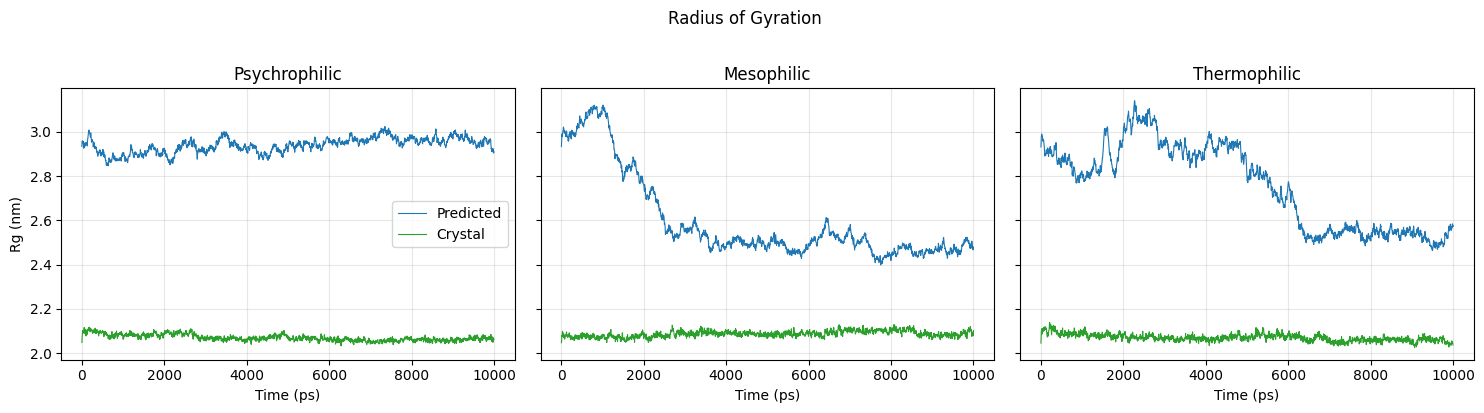

In [17]:
import matplotlib.pyplot as plt
import numpy as np

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/uvsx/psychrophilic/results/gyrate.xvg',
    'Mesophilic': 'predicted/alphafold/uvsx/mesophilic/results/gyrate.xvg',
    'Thermophilic': 'predicted/alphafold/uvsx/thermophilic/results/gyrate.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/3IO5/psychrophilic/results/gyrate.xvg',
    'Mesophilic': 'crystal/3IO5/mesophilic/results/gyrate.xvg',
    'Thermophilic': 'crystal/3IO5/thermophilic/results/gyrate.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rg = d["columns"][:, 0]

        ax.plot(x, rg, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Mean Rg:            {np.mean(rg):.3f} nm")
        print(f"Std deviation:      {np.std(rg):.3f} nm")
        print(f"Mean Rg (last 25%): {np.mean(rg[len(rg)*3//4:]):.3f} nm")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Rg (nm)")
axes[0].legend()

fig.suptitle("Radius of Gyration", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/UvsX_vs_3IO5_RG.png', dpi=300, bbox_inches='tight')
plt.show()


Psychrophilic - Predicted
Mean Rmsf:            0.401 nm
Std deviation:      0.242 nm
Mean Rmsf (last 25%): 0.660 nm

Psychrophilic - Crystal
Mean Rmsf:            0.133 nm
Std deviation:      0.057 nm
Mean Rmsf (last 25%): 0.160 nm

Mesophilic - Predicted
Mean Rmsf:            0.526 nm
Std deviation:      0.411 nm
Mean Rmsf (last 25%): 0.983 nm

Mesophilic - Crystal
Mean Rmsf:            0.154 nm
Std deviation:      0.064 nm
Mean Rmsf (last 25%): 0.206 nm

Thermophilic - Predicted
Mean Rmsf:            0.624 nm
Std deviation:      0.360 nm
Mean Rmsf (last 25%): 1.047 nm

Thermophilic - Crystal
Mean Rmsf:            0.158 nm
Std deviation:      0.065 nm
Mean Rmsf (last 25%): 0.197 nm


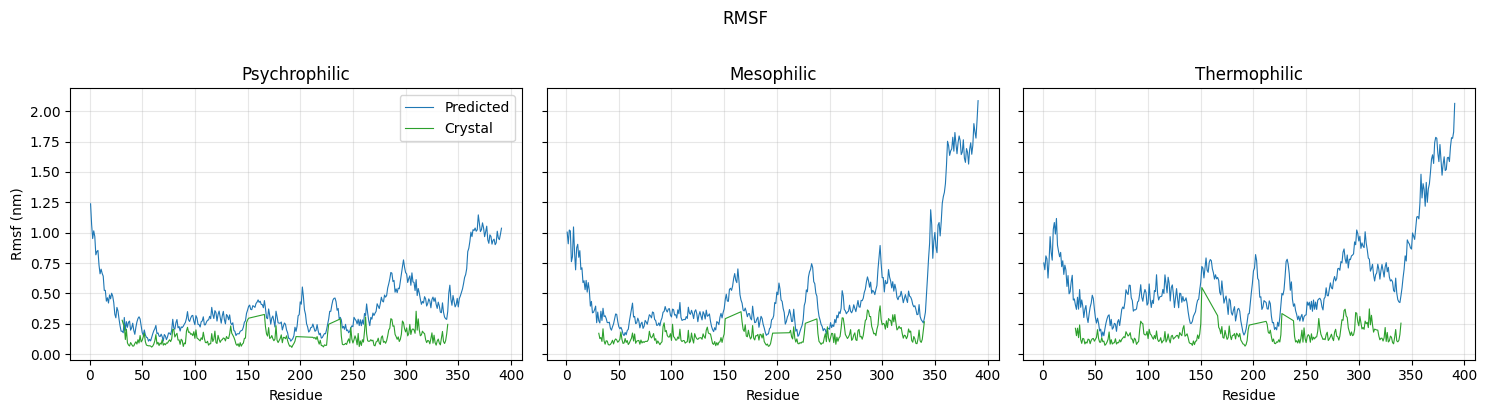

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from src.biotools.fasta_tools import *

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/uvsx/psychrophilic/results/rmsf.xvg',
    'Mesophilic': 'predicted/alphafold/uvsx/mesophilic/results/rmsf.xvg',
    'Thermophilic': 'predicted/alphafold/uvsx/thermophilic/results/rmsf.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/3IO5/psychrophilic/results/rmsf.xvg',
    'Mesophilic': 'crystal/3IO5/mesophilic/results/rmsf.xvg',
    'Thermophilic': 'crystal/3IO5/thermophilic/results/rmsf.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

# Get motifs
# seq=ExtractSequence(protein, '../../../../uvsx/data/curated_database/filtered_curated_database.fasta')
# walker_a=r"[GA]....[GF]K[TS]"
# matches_a = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_a, seq)]
# a_start=matches_a[0][0]
# a_end=matches_a[0][1]

# walker_b=r"[AVILMFWY]{2,}"
# matches_b = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_b, seq)]
# b_start=matches_b[18][0]
# b_end=matches_b[18][1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rmsf = d["columns"][:, 0]

        ax.plot(x, rmsf, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Mean Rmsf:            {np.mean(rmsf):.3f} nm")
        print(f"Std deviation:      {np.std(rmsf):.3f} nm")
        print(f"Mean Rmsf (last 25%): {np.mean(rmsf[len(rmsf)*3//4:]):.3f} nm")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

    # # showing walker a and b
    # ax.axvline(a_start, color="k", linestyle="--")
    # ax.axvline(a_end, color="k", linestyle="--")
    # ax.axvline(b_start, color="k", linestyle="--")
    # ax.axvline(b_end, color="k", linestyle="--")

axes[0].set_ylabel("Rmsf (nm)")
axes[0].legend()

fig.suptitle("RMSF", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/UvsX_vs_3IO5_RMSF.png', dpi=300, bbox_inches='tight')
plt.show()


Psychrophilic - Predicted
Final RMSD:         0.327 nm (3.3 Å)
Mean RMSD:          0.318 nm (3.2 Å)
Mean (last 25%):    0.336 nm (3.4 Å)

Psychrophilic - Crystal
Final RMSD:         0.399 nm (4.0 Å)
Mean RMSD:          0.291 nm (2.9 Å)
Mean (last 25%):    0.336 nm (3.4 Å)

Mesophilic - Predicted
Final RMSD:         0.390 nm (3.9 Å)
Mean RMSD:          0.341 nm (3.4 Å)
Mean (last 25%):    0.393 nm (3.9 Å)

Mesophilic - Crystal
Final RMSD:         0.359 nm (3.6 Å)
Mean RMSD:          0.341 nm (3.4 Å)
Mean (last 25%):    0.350 nm (3.5 Å)

Thermophilic - Predicted
Final RMSD:         0.420 nm (4.2 Å)
Mean RMSD:          0.442 nm (4.4 Å)
Mean (last 25%):    0.425 nm (4.3 Å)

Thermophilic - Crystal
Final RMSD:         0.448 nm (4.5 Å)
Mean RMSD:          0.402 nm (4.0 Å)
Mean (last 25%):    0.449 nm (4.5 Å)


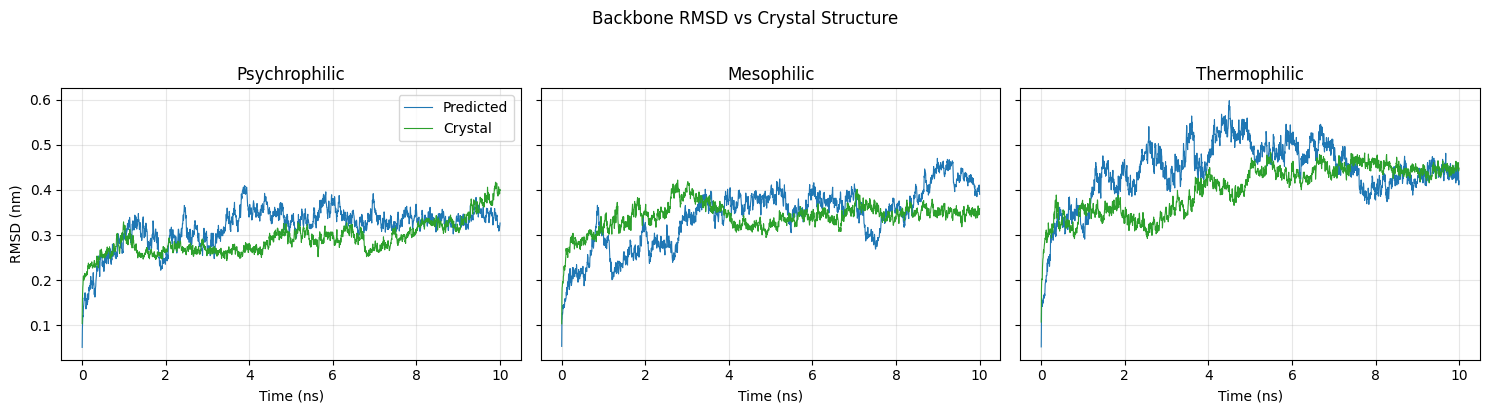

In [19]:
import matplotlib.pyplot as plt
import numpy as np

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/9GBG/psychrophilic/results/rmsd.xvg',
    'Mesophilic': 'predicted/alphafold/9GBG/mesophilic/results/rmsd.xvg',
    'Thermophilic': 'predicted/alphafold/9GBG/thermophilic/results/rmsd.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/9GBG/psychrophilic/results/rmsd.xvg',
    'Mesophilic': 'crystal/9GBG/mesophilic/results/rmsd.xvg',
    'Thermophilic': 'crystal/9GBG/thermophilic/results/rmsd.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rmsd = d["columns"][:, 0]

        ax.plot(x, rmsd, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Final RMSD:         {rmsd[-1]:.3f} nm ({rmsd[-1]*10:.1f} Å)")
        print(f"Mean RMSD:          {np.mean(rmsd):.3f} nm ({np.mean(rmsd)*10:.1f} Å)")
        print(f"Mean (last 25%):    {np.mean(rmsd[len(rmsd)*3//4:]):.3f} nm "
              f"({np.mean(rmsd[len(rmsd)*3//4:])*10:.1f} Å)")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("RMSD (nm)")
axes[0].legend()

fig.suptitle("Backbone RMSD vs Crystal Structure", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/9GBG_crystal_vs_9GBG_predicted_RMSD.png', dpi=300, bbox_inches='tight')
plt.show()


Psychrophilic - Predicted
Mean Rg:            2.268 nm
Std deviation:      0.016 nm
Mean Rg (last 25%): 2.253 nm

Psychrophilic - Crystal
Mean Rg:            2.092 nm
Std deviation:      0.014 nm
Mean Rg (last 25%): 2.081 nm

Mesophilic - Predicted
Mean Rg:            2.223 nm
Std deviation:      0.020 nm
Mean Rg (last 25%): 2.233 nm

Mesophilic - Crystal
Mean Rg:            2.098 nm
Std deviation:      0.019 nm
Mean Rg (last 25%): 2.082 nm

Thermophilic - Predicted
Mean Rg:            2.235 nm
Std deviation:      0.019 nm
Mean Rg (last 25%): 2.218 nm

Thermophilic - Crystal
Mean Rg:            2.091 nm
Std deviation:      0.022 nm
Mean Rg (last 25%): 2.069 nm


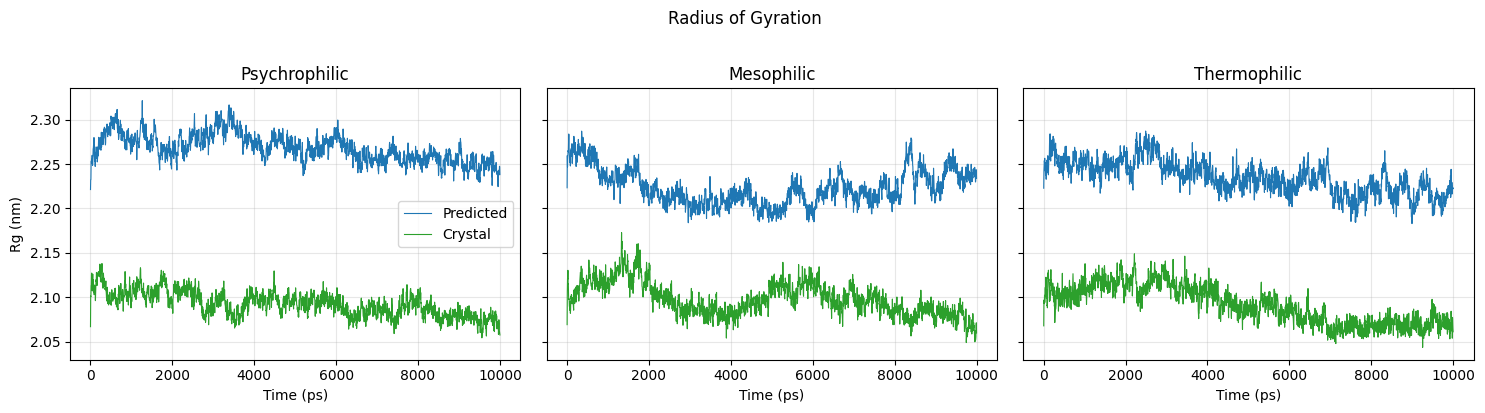

In [20]:
import matplotlib.pyplot as plt
import numpy as np

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/9GBG/psychrophilic/results/gyrate.xvg',
    'Mesophilic': 'predicted/alphafold/9GBG/mesophilic/results/gyrate.xvg',
    'Thermophilic': 'predicted/alphafold/9GBG/thermophilic/results/gyrate.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/9GBG/psychrophilic/results/gyrate.xvg',
    'Mesophilic': 'crystal/9GBG/mesophilic/results/gyrate.xvg',
    'Thermophilic': 'crystal/9GBG/thermophilic/results/gyrate.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rg = d["columns"][:, 0]

        ax.plot(x, rg, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Mean Rg:            {np.mean(rg):.3f} nm")
        print(f"Std deviation:      {np.std(rg):.3f} nm")
        print(f"Mean Rg (last 25%): {np.mean(rg[len(rg)*3//4:]):.3f} nm")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Rg (nm)")
axes[0].legend()

fig.suptitle("Radius of Gyration", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/9GBG_crystal_vs_9GBG_predicted_RG.png', dpi=300, bbox_inches='tight')
plt.show()


Psychrophilic - Predicted
Mean Rmsf:            0.178 nm
Std deviation:      0.118 nm
Mean Rmsf (last 25%): 0.152 nm

Psychrophilic - Crystal
Mean Rmsf:            0.142 nm
Std deviation:      0.094 nm
Mean Rmsf (last 25%): 0.130 nm

Mesophilic - Predicted
Mean Rmsf:            0.182 nm
Std deviation:      0.133 nm
Mean Rmsf (last 25%): 0.164 nm

Mesophilic - Crystal
Mean Rmsf:            0.165 nm
Std deviation:      0.112 nm
Mean Rmsf (last 25%): 0.154 nm

Thermophilic - Predicted
Mean Rmsf:            0.191 nm
Std deviation:      0.126 nm
Mean Rmsf (last 25%): 0.173 nm

Thermophilic - Crystal
Mean Rmsf:            0.168 nm
Std deviation:      0.133 nm
Mean Rmsf (last 25%): 0.159 nm


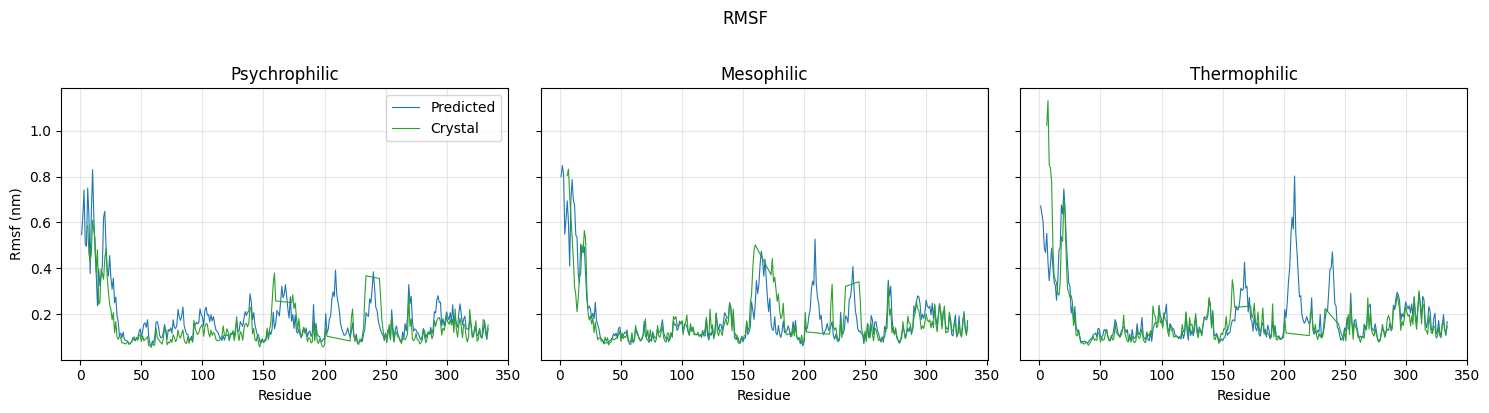

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from src.biotools.fasta_tools import *

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/9GBG/psychrophilic/results/rmsf.xvg',
    'Mesophilic': 'predicted/alphafold/9GBG/mesophilic/results/rmsf.xvg',
    'Thermophilic': 'predicted/alphafold/9GBG/thermophilic/results/rmsf.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/9GBG/psychrophilic/results/rmsf.xvg',
    'Mesophilic': 'crystal/9GBG/mesophilic/results/rmsf.xvg',
    'Thermophilic': 'crystal/9GBG/thermophilic/results/rmsf.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

# Get motifs
# seq=ExtractSequence(protein, '../../../../uvsx/data/curated_database/filtered_curated_database.fasta')
# walker_a=r"[GA]....[GF]K[TS]"
# matches_a = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_a, seq)]
# a_start=matches_a[0][0]
# a_end=matches_a[0][1]

# walker_b=r"[AVILMFWY]{2,}"
# matches_b = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_b, seq)]
# b_start=matches_b[18][0]
# b_end=matches_b[18][1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rmsf = d["columns"][:, 0]

        ax.plot(x, rmsf, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Mean Rmsf:            {np.mean(rmsf):.3f} nm")
        print(f"Std deviation:      {np.std(rmsf):.3f} nm")
        print(f"Mean Rmsf (last 25%): {np.mean(rmsf[len(rmsf)*3//4:]):.3f} nm")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

    # # showing walker a and b
    # ax.axvline(a_start, color="k", linestyle="--")
    # ax.axvline(a_end, color="k", linestyle="--")
    # ax.axvline(b_start, color="k", linestyle="--")
    # ax.axvline(b_end, color="k", linestyle="--")

axes[0].set_ylabel("Rmsf (nm)")
axes[0].legend()

fig.suptitle("RMSF", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/9GBG_crystal_vs_9GBG_predicted_RMSF.png', dpi=300, bbox_inches='tight')
plt.show()


Psychrophilic - Predicted
Final RMSD:         1.036 nm (10.4 Å)
Mean RMSD:          0.583 nm (5.8 Å)
Mean (last 25%):    0.737 nm (7.4 Å)

Psychrophilic - Crystal
Final RMSD:         0.476 nm (4.8 Å)
Mean RMSD:          0.439 nm (4.4 Å)
Mean (last 25%):    0.447 nm (4.5 Å)

Mesophilic - Predicted
Final RMSD:         1.034 nm (10.3 Å)
Mean RMSD:          0.779 nm (7.8 Å)
Mean (last 25%):    0.980 nm (9.8 Å)

Mesophilic - Crystal
Final RMSD:         0.430 nm (4.3 Å)
Mean RMSD:          0.427 nm (4.3 Å)
Mean (last 25%):    0.496 nm (5.0 Å)

Thermophilic - Predicted
Final RMSD:         0.664 nm (6.6 Å)
Mean RMSD:          0.696 nm (7.0 Å)
Mean (last 25%):    0.755 nm (7.5 Å)

Thermophilic - Crystal
Final RMSD:         0.491 nm (4.9 Å)
Mean RMSD:          0.450 nm (4.5 Å)
Mean (last 25%):    0.478 nm (4.8 Å)


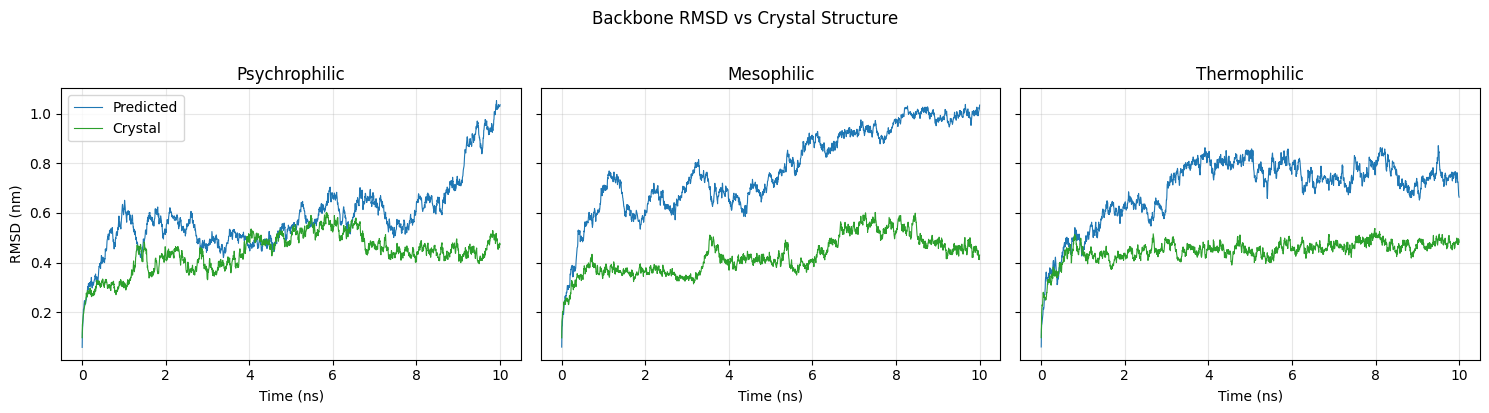

In [23]:
import matplotlib.pyplot as plt
import numpy as np

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/7Z3M/psychrophilic/results/rmsd.xvg',
    'Mesophilic': 'predicted/alphafold/7Z3M/mesophilic/results/rmsd.xvg',
    'Thermophilic': 'predicted/alphafold/7Z3M/thermophilic/results/rmsd.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/7Z3M/psychrophilic/results/rmsd.xvg',
    'Mesophilic': 'crystal/7Z3M/mesophilic/results/rmsd.xvg',
    'Thermophilic': 'crystal/7Z3M/thermophilic/results/rmsd.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rmsd = d["columns"][:, 0]

        ax.plot(x, rmsd, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Final RMSD:         {rmsd[-1]:.3f} nm ({rmsd[-1]*10:.1f} Å)")
        print(f"Mean RMSD:          {np.mean(rmsd):.3f} nm ({np.mean(rmsd)*10:.1f} Å)")
        print(f"Mean (last 25%):    {np.mean(rmsd[len(rmsd)*3//4:]):.3f} nm "
              f"({np.mean(rmsd[len(rmsd)*3//4:])*10:.1f} Å)")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("RMSD (nm)")
axes[0].legend()

fig.suptitle("Backbone RMSD vs Crystal Structure", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/7Z3M_crystal_vs_7Z3M_predicted_RMSD.png', dpi=300, bbox_inches='tight')
plt.show()


Psychrophilic - Predicted
Mean Rg:            2.469 nm
Std deviation:      0.046 nm
Mean Rg (last 25%): 2.453 nm

Psychrophilic - Crystal
Mean Rg:            2.193 nm
Std deviation:      0.030 nm
Mean Rg (last 25%): 2.181 nm

Mesophilic - Predicted
Mean Rg:            2.360 nm
Std deviation:      0.082 nm
Mean Rg (last 25%): 2.257 nm

Mesophilic - Crystal
Mean Rg:            2.187 nm
Std deviation:      0.017 nm
Mean Rg (last 25%): 2.196 nm

Thermophilic - Predicted
Mean Rg:            2.416 nm
Std deviation:      0.050 nm
Mean Rg (last 25%): 2.402 nm

Thermophilic - Crystal
Mean Rg:            2.117 nm
Std deviation:      0.034 nm
Mean Rg (last 25%): 2.093 nm


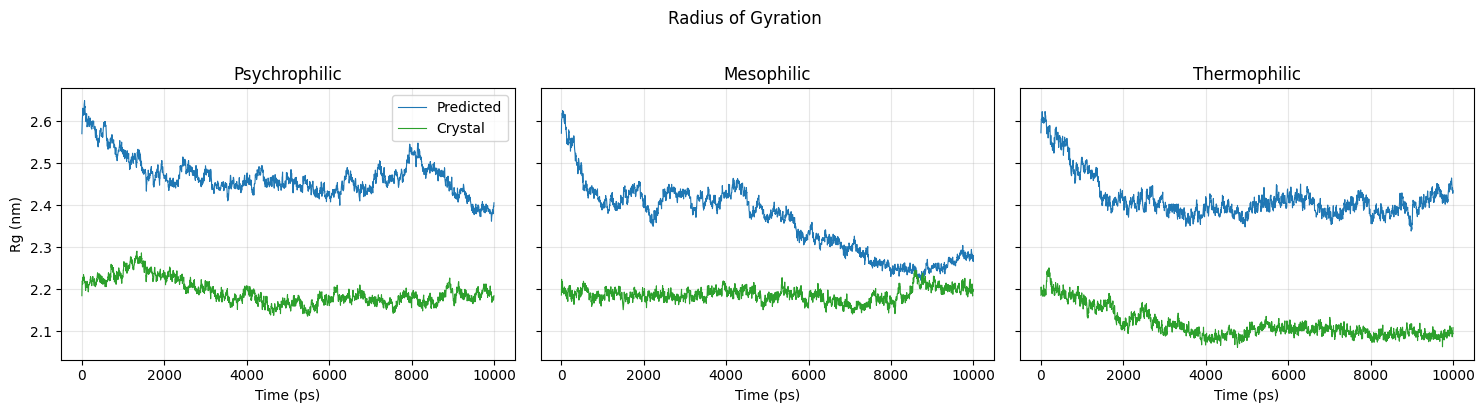

In [24]:
import matplotlib.pyplot as plt
import numpy as np

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/7Z3M/psychrophilic/results/gyrate.xvg',
    'Mesophilic': 'predicted/alphafold/7Z3M/mesophilic/results/gyrate.xvg',
    'Thermophilic': 'predicted/alphafold/7Z3M/thermophilic/results/gyrate.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/7Z3M/psychrophilic/results/gyrate.xvg',
    'Mesophilic': 'crystal/7Z3M/mesophilic/results/gyrate.xvg',
    'Thermophilic': 'crystal/7Z3M/thermophilic/results/gyrate.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rg = d["columns"][:, 0]

        ax.plot(x, rg, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Mean Rg:            {np.mean(rg):.3f} nm")
        print(f"Std deviation:      {np.std(rg):.3f} nm")
        print(f"Mean Rg (last 25%): {np.mean(rg[len(rg)*3//4:]):.3f} nm")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Rg (nm)")
axes[0].legend()

fig.suptitle("Radius of Gyration", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/7Z3M_crystal_vs_7Z3M_predicted_RG.png', dpi=300, bbox_inches='tight')
plt.show()


Psychrophilic - Predicted
Mean Rmsf:            0.263 nm
Std deviation:      0.205 nm
Mean Rmsf (last 25%): 0.282 nm

Psychrophilic - Crystal
Mean Rmsf:            0.175 nm
Std deviation:      0.174 nm
Mean Rmsf (last 25%): 0.135 nm

Mesophilic - Predicted
Mean Rmsf:            0.410 nm
Std deviation:      0.320 nm
Mean Rmsf (last 25%): 0.413 nm

Mesophilic - Crystal
Mean Rmsf:            0.174 nm
Std deviation:      0.153 nm
Mean Rmsf (last 25%): 0.153 nm

Thermophilic - Predicted
Mean Rmsf:            0.274 nm
Std deviation:      0.214 nm
Mean Rmsf (last 25%): 0.290 nm

Thermophilic - Crystal
Mean Rmsf:            0.162 nm
Std deviation:      0.132 nm
Mean Rmsf (last 25%): 0.149 nm


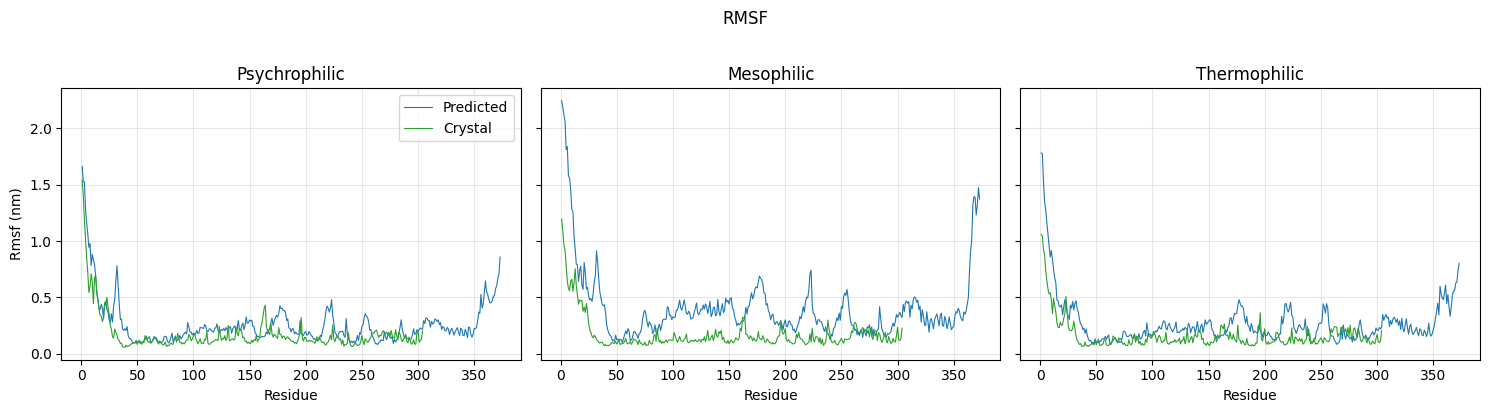

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from src.biotools.fasta_tools import *

files_uvsx = {
    'Psychrophilic': 'predicted/alphafold/7Z3M/psychrophilic/results/rmsf.xvg',
    'Mesophilic': 'predicted/alphafold/7Z3M/mesophilic/results/rmsf.xvg',
    'Thermophilic': 'predicted/alphafold/7Z3M/thermophilic/results/rmsf.xvg',
}

files_3IO5 = {
    'Psychrophilic': 'crystal/7Z3M/psychrophilic/results/rmsf.xvg',
    'Mesophilic': 'crystal/7Z3M/mesophilic/results/rmsf.xvg',
    'Thermophilic': 'crystal/7Z3M/thermophilic/results/rmsf.xvg',
}

datasets = {
    "Predicted": files_uvsx,
    "Crystal": files_3IO5,
}

colors = {
    "Predicted": "tab:blue",
    "Crystal": "tab:green",
}

conditions = ["Psychrophilic", "Mesophilic", "Thermophilic"]

# Get motifs
# seq=ExtractSequence(protein, '../../../../uvsx/data/curated_database/filtered_curated_database.fasta')
# walker_a=r"[GA]....[GF]K[TS]"
# matches_a = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_a, seq)]
# a_start=matches_a[0][0]
# a_end=matches_a[0][1]

# walker_b=r"[AVILMFWY]{2,}"
# matches_b = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_b, seq)]
# b_start=matches_b[18][0]
# b_end=matches_b[18][1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, condition in zip(axes, conditions):
    for dataset_label, files in datasets.items():
        d = parse_xvg(files[condition])

        x = d["time"]
        rmsf = d["columns"][:, 0]

        ax.plot(x, rmsf, linewidth=0.8, label=dataset_label,
                 color=colors[dataset_label])

        print(f"\n{condition} - {dataset_label}")
        print(f"Mean Rmsf:            {np.mean(rmsf):.3f} nm")
        print(f"Std deviation:      {np.std(rmsf):.3f} nm")
        print(f"Mean Rmsf (last 25%): {np.mean(rmsf[len(rmsf)*3//4:]):.3f} nm")

    ax.set_title(condition)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

    # # showing walker a and b
    # ax.axvline(a_start, color="k", linestyle="--")
    # ax.axvline(a_end, color="k", linestyle="--")
    # ax.axvline(b_start, color="k", linestyle="--")
    # ax.axvline(b_end, color="k", linestyle="--")

axes[0].set_ylabel("Rmsf (nm)")
axes[0].legend()

fig.suptitle("RMSF", y=1.02)

plt.tight_layout()
plt.savefig('../../plots/7Z3M_crystal_vs_7Z3M_predicted_RMSF.png', dpi=300, bbox_inches='tight')
plt.show()